# EU Environmental Protection Investment Analysis

In [1]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import eurostat
import textwrap
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib

## Global Settings

In [53]:
# Get current date in YYYYMMDD format
current_date = datetime.now().strftime("%Y%m%d")

# Define the base directory for outputs
FIGURES_PATH = os.path.join("..", "figures")
MODELS_PATH = os.path.join("..", "models")
RESULTS_PATH = os.path.join("..", "results")
DATA_PATH = os.path.join("..", "data")

# Ensure the directory exists
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)
os.makedirs(DATA_PATH, exist_ok=True)

print(f"Global paths set:\n \
      - Figures: {os.path.abspath(FIGURES_PATH)}\n \
      - Models: {os.path.abspath(MODELS_PATH)}\n \
      - Results: {os.path.abspath(RESULTS_PATH)}\n \
      - Data: {os.path.abspath(DATA_PATH)}")

Global paths set:
       - Figures: /home/daniel/projects/SS2026_TU_Wien/Data_Stewardship/Environmental_Protection_Investment_Analysis/figures
       - Models: /home/daniel/projects/SS2026_TU_Wien/Data_Stewardship/Environmental_Protection_Investment_Analysis/models
       - Results: /home/daniel/projects/SS2026_TU_Wien/Data_Stewardship/Environmental_Protection_Investment_Analysis/results
       - Data: /home/daniel/projects/SS2026_TU_Wien/Data_Stewardship/Environmental_Protection_Investment_Analysis/data


## Data Preprocessing

In [54]:
def get_clean_eurostat_data(dataset_code, unit_filter, category_param, category_label, value_name='value'):
    """
    Downloads, cleans and melts Eurostat data. 
    Preserves all dimension columns for flexible filtering afterwards.
    """
    # Download
    df = eurostat.get_data_df(dataset_code)

    # Save raw data to /data/raw ---
    raw_dir = os.path.join(DATA_PATH, "raw")
    os.makedirs(raw_dir, exist_ok=True)
    
    raw_filename = f"{current_date}_raw_{dataset_code}.csv"
    raw_path = os.path.join(raw_dir, raw_filename)
    
    # Save the untouched original dataframe
    df.to_csv(raw_path, index=False)
    print(f"Successfully saved raw data for {dataset_code} to: {raw_path}")
    
    # Standardize geo column
    df = df.rename(columns={'geo\\TIME_PERIOD': 'geo'})
    
    # Filter by unit and drop freq
    df_clean = df[df['unit'] == unit_filter].drop(columns=['freq'], errors='ignore').copy()
    
    # Remove regional aggregates
    aggregates = ['EU27_2020', 'EU28', 'EA19', 'EA20']
    df_clean = df_clean[~df_clean['geo'].isin(aggregates)]
    
    # Identify year columns
    year_cols = [col for col in df_clean.columns if str(col).isdigit()]
    
    # Map labels
    geo_labels = eurostat.get_dic(dataset_code, par='geo', frmt='dict')
    cat_labels = eurostat.get_dic(dataset_code, par=category_param, frmt='dict')
    
    df_clean['country_name'] = df_clean['geo'].map(geo_labels)
    df_clean[category_label] = df_clean[category_param].map(cat_labels)
    
    # Identify all non-year columns to keep as ID variables
    id_vars = [col for col in df_clean.columns if col not in year_cols]
    
    # Melt to long format
    df_long = df_clean.melt(
        id_vars=id_vars, 
        value_vars=year_cols, 
        var_name='year', 
        value_name=value_name
    )
    
    # Conversions
    df_long['year'] = df_long['year'].astype(int)
    df_long[value_name] = pd.to_numeric(df_long[value_name], errors='coerce')
    
    return df_long

In [55]:
def plot_missing_data_heatmap(df_long, value_col, title, filename):
    """
    Creates a heatmap showing the count of missing values per country and year.
    """
    # Create helper for missing values
    df_temp = df_long.copy()
    df_temp['is_missing'] = df_temp[value_col].isnull().astype(int)
    
    # Pivot for the heatmap
    missing_counts = df_temp.pivot_table(
        index='country_name', 
        columns='year', 
        values='is_missing', 
        aggfunc='sum'
    )
    
    # Plotting
    plt.figure(figsize=(16, 10))
    sns.heatmap(missing_counts, annot=True, fmt='g', cmap='YlOrRd', 
                linewidths=.5, linecolor='lightgray',
                cbar_kws={'label': 'Number of Missing Values'})
    
    # 4. Save figure using the global path
    # save_path = os.path.join(FIGURES_PATH, filename)
    # plt.savefig(save_path, bbox_inches='tight', dpi=300)
    
    # print(f"Plot saved successfully to: {save_path}")

    plt.title(title)
    plt.xlabel('Year')
    plt.ylabel('Country')
    plt.show()

### Environmental Protection Data

Successfully saved raw data for env_ac_epigg1 to: ../data/raw/20260503_raw_env_ac_epigg1.csv


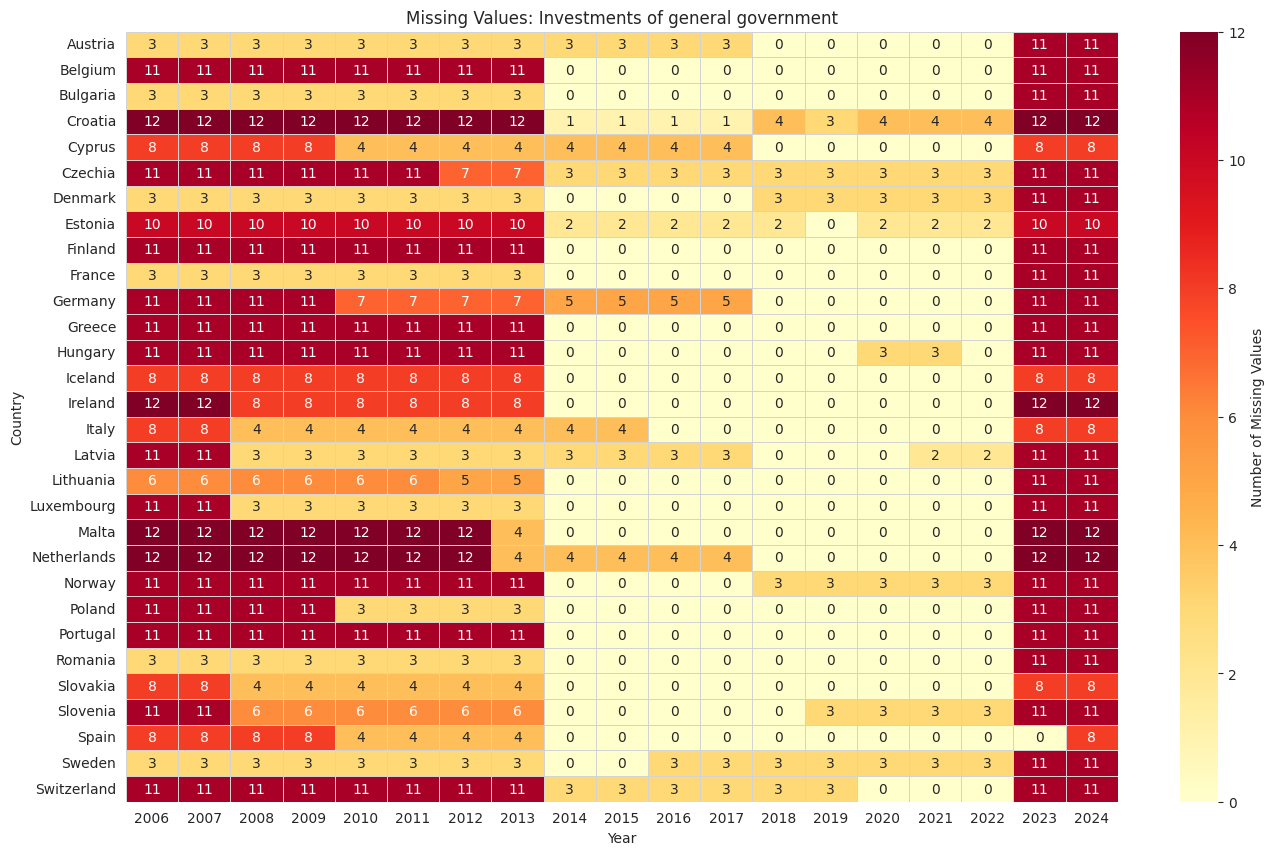

Successfully saved raw data for env_ac_epissp1 to: ../data/raw/20260503_raw_env_ac_epissp1.csv


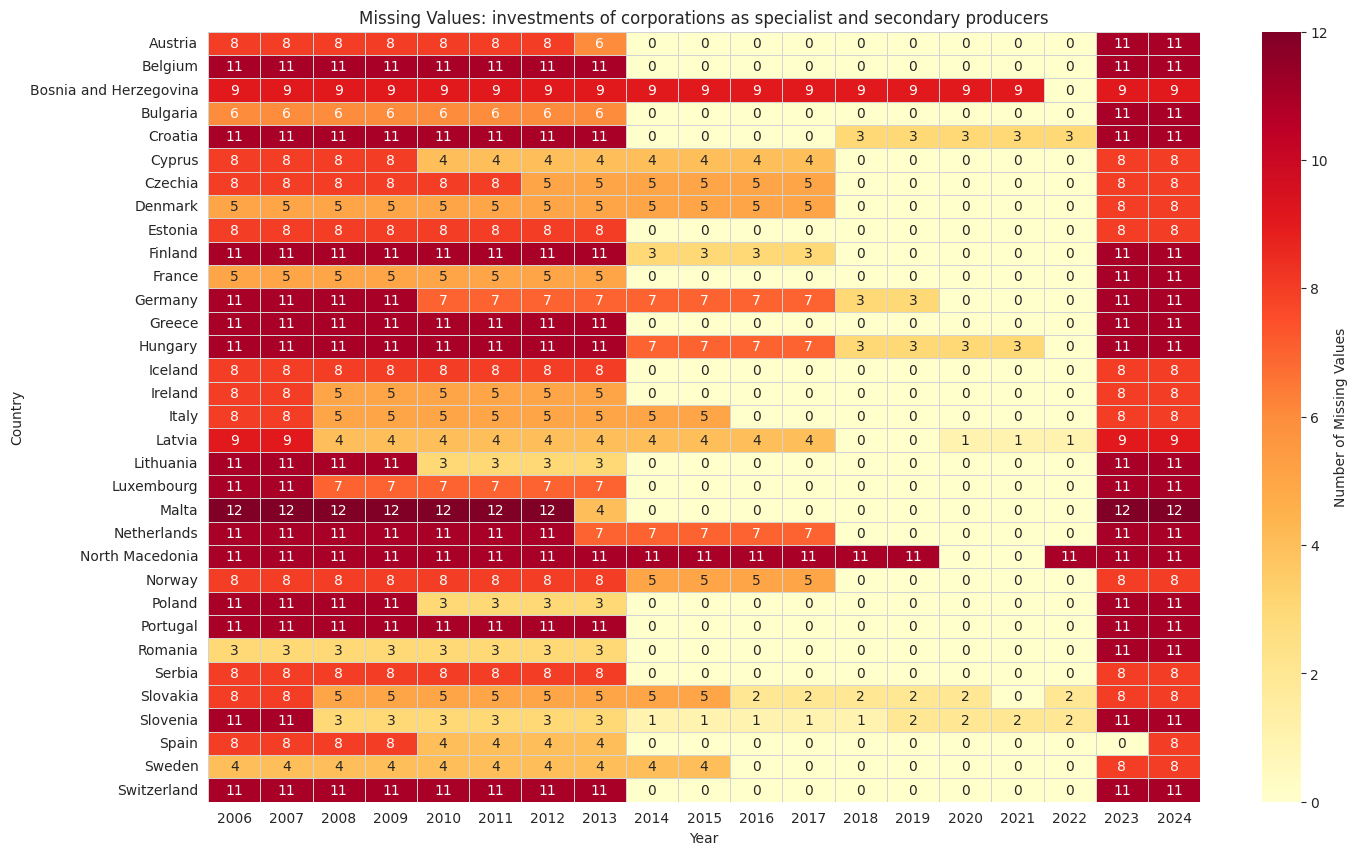

In [56]:
# Dataset 1: General Government Investments
df_gov = get_clean_eurostat_data(dataset_code='env_ac_epigg1', unit_filter='MIO_EUR', category_param='ceparema', category_label='activity', value_name='inv_gov')
plot_missing_data_heatmap(df_gov, 'inv_gov', 'Missing Values: Investments of general government', filename='missing_data_heatmap_gov_investment.png')

# Dataset 2: Corporate Investments - Specialist and secondary producers
df_corp_spec = get_clean_eurostat_data(dataset_code='env_ac_epissp1', unit_filter='MIO_EUR', category_param='ceparema', category_label='activity', value_name='inv_corp_spec')
plot_missing_data_heatmap(df_corp_spec, 'inv_corp_spec', 'Missing Values: investments of corporations as specialist and secondary producers', filename='missing_data_heatmap_corp_spec_investment.png')

Successfully saved raw data for env_ac_epiap1 to: ../data/raw/20260503_raw_env_ac_epiap1.csv


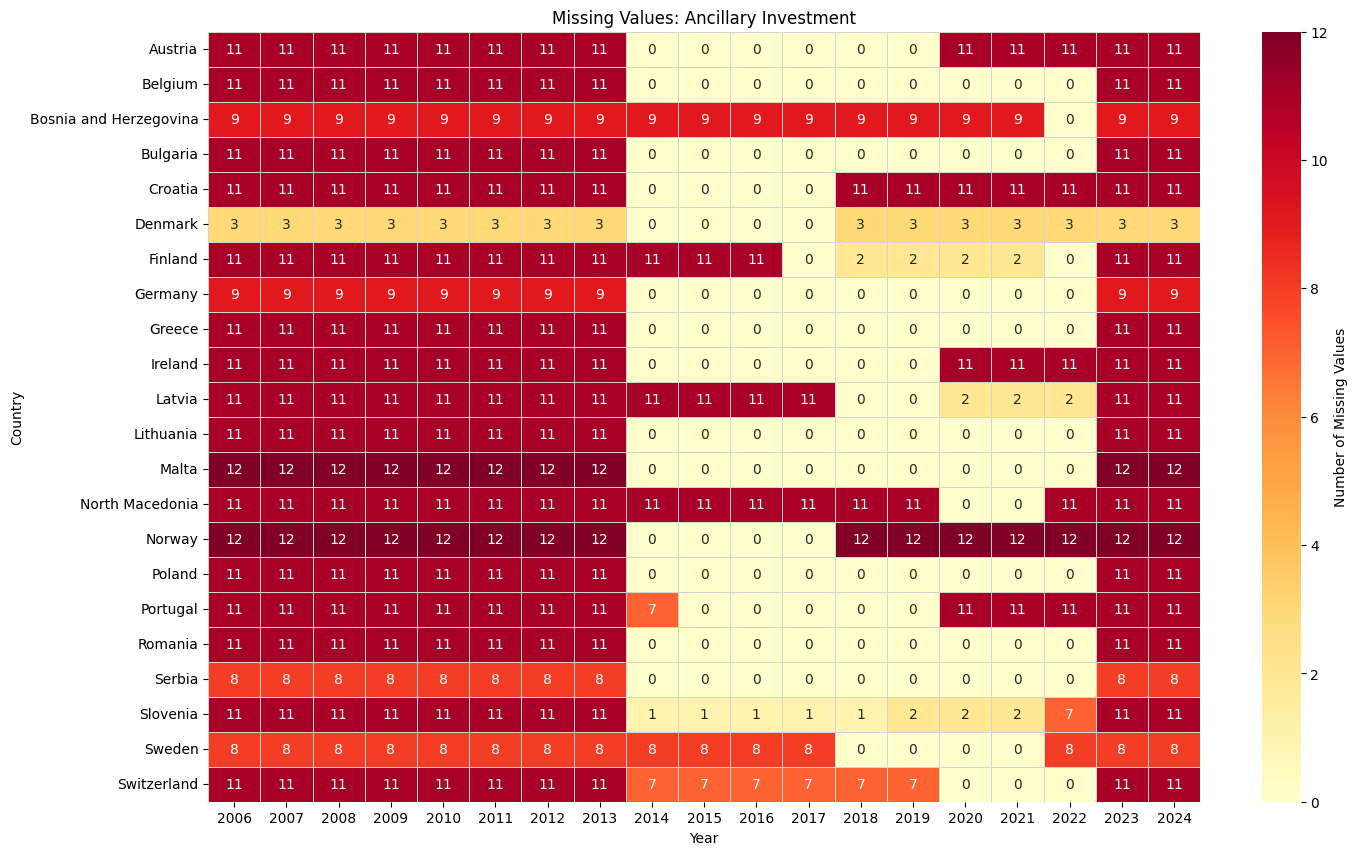

In [7]:
# Dataset 2: Corporate Investments - Ancillary producers
df_corp_anc_raw = get_clean_eurostat_data('env_ac_epiap1', 'MIO_EUR', 'ceparema', 'activity', 'inv_corp_anc')

# Filtering Dataset 
# Logic:
# EP_BSN     = Focus on the total business sector (excluding household/gov)
# EPS_INV_PT = End-of-pipe technologies (specific assets)
# EPS_INV_PP = Integrated technologies (cleaner technologies)
df_corp_anc = df_corp_anc_raw[
    (df_corp_anc_raw['nace_r2'] == 'EP_BSN') & 
    (df_corp_anc_raw['env_econ'].isin(['EPS_INV_PT', 'EPS_INV_PP']))
].copy()

# Data Aggregation
# Group by core dimensions and sum the investment values to add End-of-Pipe and Integrated to a total
# min_count=1 ensures that if all values in a group are NaN, the result remains NaN 
df_corp_anc = df_corp_anc.groupby(['geo', 'year', 'ceparema', 'country_name', 'activity'], as_index=False)['inv_corp_anc'].sum(min_count=1)

plot_missing_data_heatmap(df_corp_anc, 'inv_corp_anc', 'Missing Values: Ancillary Investment', filename='missing_data_heatmap_corp_anc_investment.png')

Data availability for ancillary producers (integrated technologies) is more fragmented than for government expenditures. Some nations are omitted from the analysis due to non-reporting or lack of data within the specific Eurostat classifications (EP_BSN).

In [8]:
# Define valid years for analysis
valid_years = range(2014, 2023) # 2014 - 2022

# Filter datasets to include only valid years
df_gov = df_gov[df_gov['year'].isin(valid_years)].copy()
df_corp_spec = df_corp_spec[df_corp_spec['year'].isin(valid_years)].copy()
df_corp_anc = df_corp_anc[df_corp_anc['year'].isin(valid_years)].copy()

In [9]:
df_corp_spec.head()

,ceparema,unit,geo,country_name,activity,year,inv_corp_spec
2592,CEPA1,MIO_EUR,AT,Austria,Protection of ambient air and climate,2014,5.8
2593,CEPA1,MIO_EUR,BA,Bosnia and Herzegovina,Protection of ambient air and climate,2014,NaN
2594,CEPA1,MIO_EUR,BE,Belgium,Protection of ambient air and climate,2014,10.2
2595,CEPA1,MIO_EUR,BG,Bulgaria,Protection of ambient air and climate,2014,0.0
2596,CEPA1,MIO_EUR,CH,Switzerland,Protection of ambient air and climate,2014,5.8


In [10]:
df_gov.head()

,ceparema,unit,geo,country_name,activity,year,inv_gov
2544,CEPA1,MIO_EUR,AT,Austria,Protection of ambient air and climate,2014,6.2
2545,CEPA1,MIO_EUR,BE,Belgium,Protection of ambient air and climate,2014,3.5
2546,CEPA1,MIO_EUR,BG,Bulgaria,Protection of ambient air and climate,2014,1.7
2547,CEPA1,MIO_EUR,CH,Switzerland,Protection of ambient air and climate,2014,1.6
2548,CEPA1,MIO_EUR,CY,Cyprus,Protection of ambient air and climate,2014,NaN


In [11]:
df_corp_anc.head()

,geo,year,ceparema,country_name,activity,inv_corp_anc
88,AT,2014,CEPA1,Austria,Protection of ambient air and climate,103.5
89,AT,2014,CEPA2,Austria,Wastewater management,24.4
90,AT,2014,CEPA3,Austria,Waste management,26.8
91,AT,2014,CEPA4,Austria,"Protection and remediation of soil, groundwate...",28.2
92,AT,2014,CEPA5,Austria,Noise and vibration abatement (excluding workp...,20.0


In [12]:
# Convert unit from million euros to absolute euros
def convert_to_absolute_euro(df, value_col):
    # Multiply by 1 million
    df[value_col] = (df[value_col] * 1_000_000).round().astype('Int64')
    return df

# Apply to datasets
df_gov = convert_to_absolute_euro(df_gov, 'inv_gov')
df_corp_spec = convert_to_absolute_euro(df_corp_spec, 'inv_corp_spec')
df_corp_anc = convert_to_absolute_euro(df_corp_anc, 'inv_corp_anc')

### Wealth & Population Data

In [13]:
# Dataset 4: GDP per capita (Real GDP per capita, chain-linked volumes)
df_gdp_raw = get_clean_eurostat_data('sdg_08_10', 'CLV20_EUR_HAB', 'na_item', 'gdp_type')

# Filter for main GDP indicator (B1GQ) and rename column
df_gdp = df_gdp_raw[df_gdp_raw['na_item'] == 'B1GQ'].rename(columns={'value': 'gdp_per_capita'})

# Keep only years between 2014 and 2022 inclusive
df_gdp = df_gdp[df_gdp['year'].between(2014, 2022)].reset_index(drop=True)

df_gdp.head()

Successfully saved raw data for sdg_08_10 to: ../data/raw/20260503_raw_sdg_08_10.csv


,unit,na_item,geo,country_name,gdp_type,year,gdp_per_capita
0,CLV20_EUR_HAB,B1GQ,AL,Albania,Gross domestic product at market prices,2014,4130.0
1,CLV20_EUR_HAB,B1GQ,AT,Austria,Gross domestic product at market prices,2014,43070.0
2,CLV20_EUR_HAB,B1GQ,BA,Bosnia and Herzegovina,Gross domestic product at market prices,2014,0.0
3,CLV20_EUR_HAB,B1GQ,BE,Belgium,Gross domestic product at market prices,2014,39960.0
4,CLV20_EUR_HAB,B1GQ,BG,Bulgaria,Gross domestic product at market prices,2014,7770.0


In [14]:
# Dataset 5: Population data
df_pop_raw = get_clean_eurostat_data('demo_pjan', 'NR', 'age', 'age_label', value_name='population')

# Filter data with 'T' for Total (sum of males and females)
df_pop = df_pop_raw[
    (df_pop_raw['sex'] == 'T') & 
    (df_pop_raw['age'] == 'TOTAL')
].copy()

# Keep only years between 2014 and 2022 inclusive
df_pop = df_pop[df_pop['year'].between(2014, 2022)].reset_index(drop=True)

df_pop.head()

Successfully saved raw data for demo_pjan to: ../data/raw/20260503_raw_demo_pjan.csv


,unit,age,sex,geo,country_name,age_label,year,population
0,NR,TOTAL,T,AD,Andorra,Total,2014,NaN
1,NR,TOTAL,T,AL,Albania,Total,2014,2892394.0
2,NR,TOTAL,T,AM,Armenia,Total,2014,NaN
3,NR,TOTAL,T,AT,Austria,Total,2014,8507786.0
4,NR,TOTAL,T,AZ,Azerbaijan,Total,2014,9477119.0


### Merging and Enrichment of Environmental Investment Data

Merge Investment Data

In [15]:
# Start with Government Investments as the base
df_investments = df_gov[['geo', 'country_name', 'year', 'ceparema', 'activity', 'inv_gov']].copy()

# Merge Corporate Specialist and Ancillary data
for additional_df, cols in [
    (df_corp_spec, ['geo', 'year', 'ceparema', 'inv_corp_spec']),
    (df_corp_anc,  ['geo', 'year', 'ceparema', 'inv_corp_anc'])
]:
    df_investments = df_investments.merge(
        additional_df[cols],
        on=['geo', 'year', 'ceparema'],
        how='left'
    )

In [16]:
df_investments.describe()

,year,inv_gov,inv_corp_spec,inv_corp_anc
count,2862.00000,2621.0,2383.0,1339.0
mean,2018.00000,181203624.570775,150010365.086026,93031217.326363
std,2.58244,619400859.885838,602251751.949526,302465014.042645
min,2014.00000,-33400000.0,0.0,0.0
25%,2016.00000,200000.0,0.0,200000.0
50%,2018.00000,9200000.0,1800000.0,7600000.0
75%,2020.00000,69100000.0,48750000.0,49900000.0
max,2022.00000,8694500000.0,8209500000.0,3822200000.0


Negative investment figures were observed in the government sector, specifically for Estonia in 2021 and 2022. In national accounting, these anomalies could represent 'net disposals,' where the sale of existing environmental assets exceeds new acquisitions, or they may result from the repayment of investment grants and internal reclassifications. To ensure model stability and compatibility with log-transformations, these values were clipped to zero

In [17]:
# Identify numeric columns (inv_gov, inv_corp_spec, inv_corp_anc)
num_cols = df_investments.select_dtypes(include='number').columns

# Correct negative values to 0 before calculating any totals
df_investments[num_cols] = df_investments[num_cols].clip(lower=0)
print(f"Applied clipping to: {', '.join(num_cols)}")

Applied clipping to: year, inv_gov, inv_corp_spec, inv_corp_anc


In [18]:
# Calculate total corporate and overall investment before splitting
df_investments['inv_corp_total'] = df_investments['inv_corp_spec'].fillna(0) + df_investments['inv_corp_anc'].fillna(0)
df_investments['inv_total'] = df_investments['inv_gov'].fillna(0) + df_investments['inv_corp_total']

Split datasets

In [19]:
# VIEW A: Sector Breakdown (For Trend Analysis)
df_cepa_breakdown = df_investments[df_investments['ceparema'] != 'TOT_CEPA'].copy()

# VIEW B: National Totals (For Regression & Clustering)
df_cepa_totals = df_investments[df_investments['ceparema'] == 'TOT_CEPA'].copy()

Enrichment of aggregate values (View B)

In [20]:
# Add GDP and Population to Totals only
for extra_df, extra_cols in [
    (df_gdp, ['geo', 'year', 'gdp_per_capita']),
    (df_pop, ['geo', 'year', 'population'])
]:
    df_cepa_totals = df_cepa_totals.merge(
        extra_df[extra_cols],
        on=['geo', 'year'],
        how='left'
    )

# Calculate Per Capita Investment
df_cepa_totals['inv_per_capita'] = df_cepa_totals['inv_total'] / df_cepa_totals['population']

In [21]:
# Record row count before merging GDP and Population
rows_before_extra = len(df_cepa_totals)

# Check for row inflation before dropping NaNs
if len(df_cepa_totals) != rows_before_extra:
    print(f"Warning: Row count changed from {rows_before_extra} to {len(df_cepa_totals)} during enrichment.")
else:
    print("Validation successful: No row inflation during GDP/Population merge.")

Validation successful: No row inflation during GDP/Population merge.


Sort columns

In [22]:
# Define column orders
cols_base = ['year', 'geo', 'country_name', 'ceparema', 'activity', 
             'inv_gov', 'inv_corp_spec', 'inv_corp_anc', 'inv_corp_total', 'inv_total']

cols_totals = cols_base + ['population', 'inv_per_capita', 'gdp_per_capita']

# Apply ordering
df_cepa_breakdown = df_cepa_breakdown[cols_base]
df_cepa_totals = df_cepa_totals[cols_totals]

# Final Check
print(f"Check: {df_cepa_totals['country_name'].nunique()} countries in Totals view.")
print(f"Check: {df_cepa_totals['ceparema'].nunique()} protection sector in Totals view.")

print(f"Check: {df_cepa_breakdown['country_name'].nunique()} countries in Breakdown view.")
print(f"Check: {df_cepa_breakdown['ceparema'].nunique()} protection sectors in Breakdown view.")

Check: 30 countries in Totals view.
Check: 1 protection sector in Totals view.
Check: 30 countries in Breakdown view.
Check: 11 protection sectors in Breakdown view.


In [23]:
# Check if row count remained constant (since df_gov is the base)
if len(df_investments) == len(df_gov):
    print("Row count check passed: No unintended row inflation.")
else:
    print(f"Warning: Row count changed from {len(df_gov)} to {len(df_investments)}!")

Row count check passed: No unintended row inflation.


### Missing Data Analysis (df_cepa_totals)

In [24]:
# 1. Define all numeric columns for type conversion
# We include both the original Int64 investment columns and the float columns
float_cols = ['population', 'inv_per_capita', 'gdp_per_capita']

# 2. Convert to standard NumPy float64
# We use float instead of int because standard numpy integers cannot handle NaN values.
# This conversion ensures full compatibility with Seaborn, Matplotlib, and Scikit-Learn.
df_cepa_totals[float_cols] = df_cepa_totals[float_cols].astype(float)

# 3. Verify data types
# All targeted columns should now show 'float64'
print(df_cepa_totals.dtypes)

year                int64
geo                object
country_name       object
ceparema           object
activity           object
inv_gov             Int64
inv_corp_spec       Int64
inv_corp_anc        Int64
inv_corp_total      Int64
inv_total           Int64
population        float64
inv_per_capita    float64
gdp_per_capita    float64
dtype: object


In [25]:
df_cepa_totals.head()

,year,geo,country_name,ceparema,activity,inv_gov,inv_corp_spec,inv_corp_anc,inv_corp_total,inv_total,population,inv_per_capita,gdp_per_capita
0,2014,AT,Austria,TOT_CEPA,Total environmental protection activities,18700000,401300000,215500000,616800000,635500000,8507786.0,74.696284,43070.0
1,2014,BE,Belgium,TOT_CEPA,Total environmental protection activities,359200000,773500000,499900000,1273400000,1632600000,11180840.0,146.017652,39960.0
2,2014,BG,Bulgaria,TOT_CEPA,Total environmental protection activities,574500000,34400000,224100000,258500000,833000000,7117453.0,117.036249,7770.0
3,2014,CH,Switzerland,TOT_CEPA,Total environmental protection activities,1030100000,407700000,460600000,868300000,1898400000,8139631.0,233.229246,75620.0
4,2014,CY,Cyprus,TOT_CEPA,Total environmental protection activities,27000000,14800000,<NA>,14800000,41800000,860032.0,48.602843,20490.0


In [26]:
# --- 1. Tabular Missing Data Analysis ---
missing_values = df_cepa_totals.isnull().sum()
missing_percent = (df_cepa_totals.isnull().sum() / len(df_cepa_totals) * 100).round(2)

# Create a summary table
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Values', ascending=False)

print("=== Missing Data Summary (df_cepa_totals) ===")
print(missing_df)

=== Missing Data Summary (df_cepa_totals) ===
                Missing Values  Percentage (%)
inv_corp_anc               139           51.48
inv_corp_spec               16            5.93
year                         0            0.00
geo                          0            0.00
country_name                 0            0.00
ceparema                     0            0.00
activity                     0            0.00
inv_gov                      0            0.00
inv_corp_total               0            0.00
inv_total                    0            0.00
population                   0            0.00
inv_per_capita               0            0.00
gdp_per_capita               0            0.00


In [27]:
# Identify countries where inv_corp_anc has more than 80% missing values
missing_stats = df_cepa_totals.groupby('country_name')['inv_corp_anc'].apply(lambda x: x.isnull().mean() * 100)
countries_to_drop = missing_stats[missing_stats > 80].index.tolist()

print(f"The following countries will be removed (>80% NaN in inv_corp_anc):")
print(countries_to_drop)

# Filter the df_final to remove identified countries
df_final_cleaned = df_cepa_totals[~df_cepa_totals['country_name'].isin(countries_to_drop)].copy()

# Quick verification of the filtering results
print(f"\nCountries before filtering: {df_cepa_totals['country_name'].nunique()}")
print(f"Countries after filtering: {df_final_cleaned['country_name'].nunique()}")

The following countries will be removed (>80% NaN in inv_corp_anc):
['Cyprus', 'Czechia', 'Denmark', 'Estonia', 'France', 'Hungary', 'Iceland', 'Italy', 'Luxembourg', 'Netherlands', 'Slovakia', 'Spain']

Countries before filtering: 30
Countries after filtering: 18


In [28]:
 # Update df_final with the cleaned version
df_cepa_totals = df_final_cleaned

/tmp/ipykernel_7030/3517333655.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_missing_land = df_cepa_totals.groupby('country_name').apply(lambda x: x.isnull().mean() * 100)


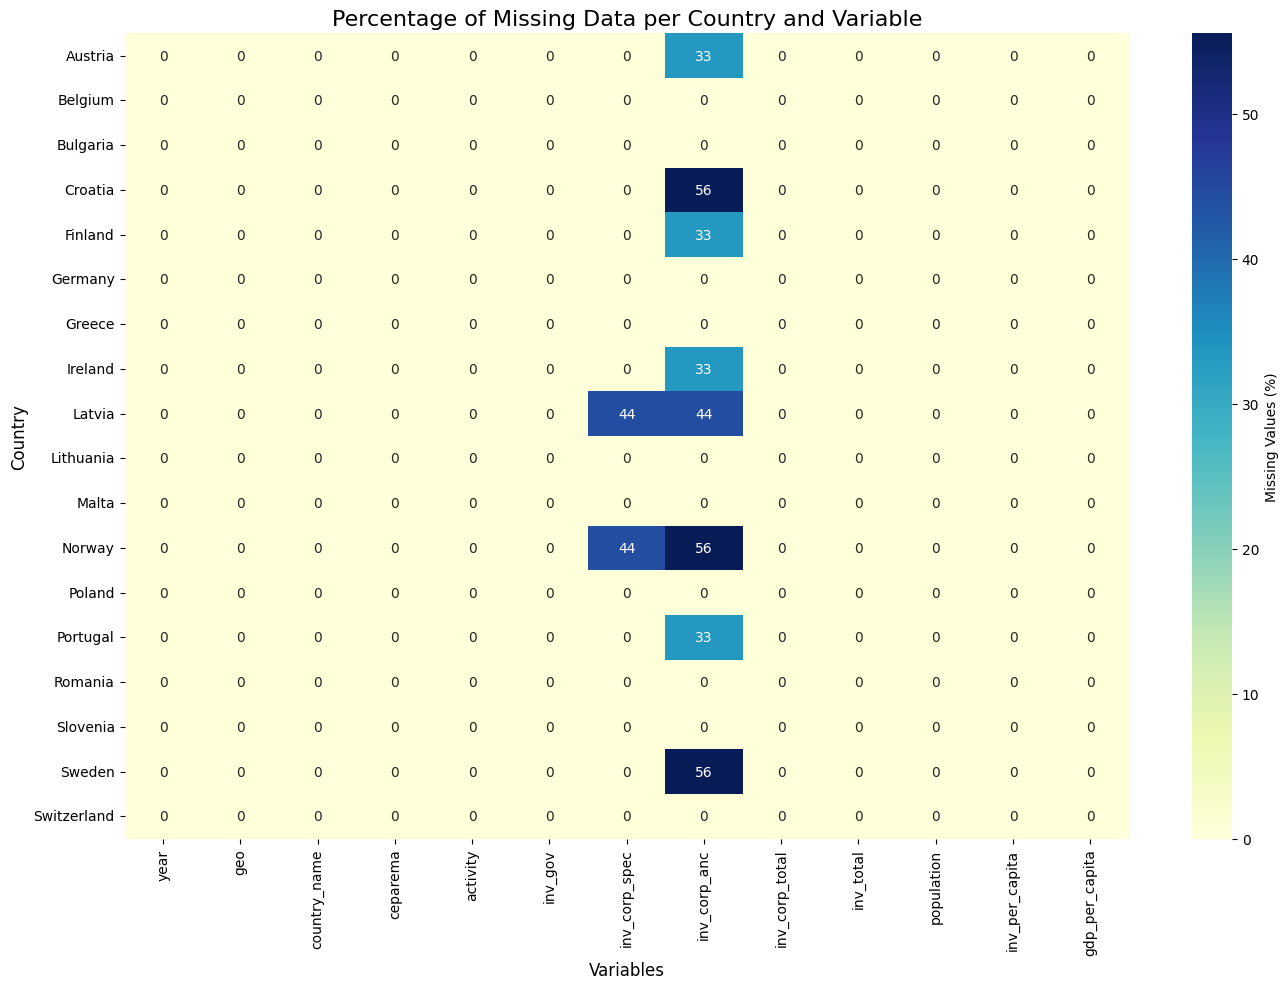

In [29]:
# 1. Calculate the percentage of missing values per country and per variable
# We group by 'country_name' and calculate the mean of the .isnull() mask
df_missing_land = df_cepa_totals.groupby('country_name').apply(lambda x: x.isnull().mean() * 100)

# 2. Visualization
plt.figure(figsize=(14, 10))
# Using a heatmap to visualize the missing data percentage
sns.heatmap(df_missing_land, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Missing Values (%)'})

plt.title("Percentage of Missing Data per Country and Variable", fontsize=16)
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.tight_layout()
plt.show()

In [30]:
def get_full_timeseries_matrix(df, column, cepa_filter):
    # Filter for the specific sector (e.g., 'CEPA1', 'CEPA2' or any other)
    df_filtered = df[df['ceparema'] == cepa_filter].copy()
    
    # Check if the filter actually returned data
    if df_filtered.empty:
        return f"No data found for sector: {cepa_filter}"
    
    # Create status indicator (. for present, X for missing)
    df_filtered['Status'] = df_filtered[column].notna().map({True: '.', False: 'X'})
    
    # Create Pivot Table
    matrix = df_filtered.pivot(index='country_name', columns='year', values='Status')
    
    # Fill actual missing years (rows not present in the data)
    matrix = matrix.fillna('X')
    
    print(f"--- Time Series Availability for: {column} | Sector: {cepa_filter} ---")
    return matrix

full_matrix = get_full_timeseries_matrix(df_cepa_totals, column='inv_corp_anc', cepa_filter='TOT_CEPA')
full_matrix

--- Time Series Availability for: inv_corp_anc | Sector: TOT_CEPA ---


year,2014,2015,2016,2017,2018,2019,2020,2021,2022
country_name,,,,,,,,,
Austria,.,.,.,.,.,.,X,X,X
Belgium,.,.,.,.,.,.,.,.,.
Bulgaria,.,.,.,.,.,.,.,.,.
Croatia,.,.,.,.,X,X,X,X,X
Finland,X,X,X,.,.,.,.,.,.
Germany,.,.,.,.,.,.,.,.,.
Greece,.,.,.,.,.,.,.,.,.
Ireland,.,.,.,.,.,.,X,X,X
Latvia,X,X,X,X,.,.,.,.,.


Interpolation is not suitable for the data

Evaluation after Handling Missing Values

In [31]:
# --- 1. Tabular Missing Data Analysis ---
missing_values = df_cepa_totals.isnull().sum()
missing_percent = (df_cepa_totals.isnull().sum() / len(df_cepa_totals) * 100).round(2)

# Create a summary table
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Values', ascending=False)

print("=== Missing Data Summary (df_cepa_totals) ===")
print(missing_df)

=== Missing Data Summary (df_cepa_totals) ===
                Missing Values  Percentage (%)
inv_corp_anc                31           19.14
inv_corp_spec                8            4.94
year                         0            0.00
geo                          0            0.00
country_name                 0            0.00
ceparema                     0            0.00
activity                     0            0.00
inv_gov                      0            0.00
inv_corp_total               0            0.00
inv_total                    0            0.00
population                   0            0.00
inv_per_capita               0            0.00
gdp_per_capita               0            0.00


Duplicate Check

In [33]:
# --- Data Quality: Duplicate Check for National Totals ---

# Define columns that must form a unique identifier for national totals
id_columns_totals = ['year', 'geo']

# Identify all rows that violate uniqueness
duplicates_totals = df_cepa_totals[df_cepa_totals.duplicated(subset=id_columns_totals, keep=False)]

# Validation output
if not duplicates_totals.empty:
    print(f"Warning: {len(duplicates_totals)} duplicate records detected in totals view.")
    # Show the first 10 duplicates for debugging
    print(duplicates_totals.sort_values(by=id_columns_totals).head(10))
else:
    print(f"Validation successful: No duplicates found for {id_columns_totals}.")

# Verification of record counts
unique_entries_totals = df_cepa_totals.groupby(id_columns_totals).ngroups
print(f"Summary: {unique_entries_totals} unique country-year records out of {len(df_cepa_totals)} total rows.")

Validation successful: No duplicates found for ['year', 'geo'].
Summary: 162 unique country-year records out of 162 total rows.


### Missing Data Analysis (df_cepa_breakdown)

In [34]:
df_cepa_breakdown.head()

,year,geo,country_name,ceparema,activity,inv_gov,inv_corp_spec,inv_corp_anc,inv_corp_total,inv_total
0,2014,AT,Austria,CEPA1,Protection of ambient air and climate,6200000,5800000,103500000,109300000,115500000
1,2014,BE,Belgium,CEPA1,Protection of ambient air and climate,3500000,10200000,161100000,171300000,174800000
2,2014,BG,Bulgaria,CEPA1,Protection of ambient air and climate,1700000,0,174900000,174900000,176600000
3,2014,CH,Switzerland,CEPA1,Protection of ambient air and climate,1600000,5800000,114200000,120000000,121600000
4,2014,CY,Cyprus,CEPA1,Protection of ambient air and climate,<NA>,<NA>,<NA>,0,0


In [35]:
# --- 1. Tabular Missing Data Analysis ---
missing_values = df_cepa_breakdown.isnull().sum()
missing_percent = (df_cepa_breakdown.isnull().sum() / len(df_cepa_breakdown) * 100).round(2)

# Create a summary table
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Values', ascending=False)

print("=== Missing Data Summary (df_cepa_breakdown) ===")
print(missing_df)

=== Missing Data Summary (df_cepa_breakdown) ===
                Missing Values  Percentage (%)
inv_corp_anc              1384           53.40
inv_corp_spec              463           17.86
inv_gov                    241            9.30
year                         0            0.00
geo                          0            0.00
country_name                 0            0.00
ceparema                     0            0.00
activity                     0            0.00
inv_corp_total               0            0.00
inv_total                    0            0.00


In [36]:
# Identify countries where inv_corp_anc has more than 80% missing values
missing_stats = df_cepa_breakdown.groupby('country_name')['inv_corp_anc'].apply(lambda x: x.isnull().mean() * 100)
countries_to_drop = missing_stats[missing_stats > 80].index.tolist()

print(f"The following countries will be removed (>80% NaN in inv_corp_anc):")
print(countries_to_drop)

# Filter the df_final to remove identified countries
df_final_cleaned = df_cepa_breakdown[~df_cepa_breakdown['country_name'].isin(countries_to_drop)].copy()

# Quick verification of the filtering results
print(f"\nCountries before filtering: {df_cepa_breakdown['country_name'].nunique()}")
print(f"Countries after filtering: {df_final_cleaned['country_name'].nunique()}")

The following countries will be removed (>80% NaN in inv_corp_anc):
['Cyprus', 'Czechia', 'Denmark', 'Estonia', 'France', 'Hungary', 'Iceland', 'Italy', 'Luxembourg', 'Netherlands', 'Slovakia', 'Spain']

Countries before filtering: 30
Countries after filtering: 18


In [37]:
 # Update df_final with the cleaned version
df_cepa_breakdown = df_final_cleaned

In [38]:
# --- 1. Tabular Missing Data Analysis ---
missing_values = df_cepa_breakdown.isnull().sum()
missing_percent = (df_cepa_breakdown.isnull().sum() / len(df_cepa_breakdown) * 100).round(2)

# Create a summary table
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Values', ascending=False)

print("=== Missing Data Summary (df_cepa_breakdown) ===")
print(missing_df)

=== Missing Data Summary (df_cepa_breakdown) ===
                Missing Values  Percentage (%)
inv_corp_anc               451           27.38
inv_corp_spec              234           14.21
inv_gov                    137            8.32
year                         0            0.00
geo                          0            0.00
country_name                 0            0.00
ceparema                     0            0.00
activity                     0            0.00
inv_corp_total               0            0.00
inv_total                    0            0.00


Duplicate Check

In [39]:
# --- Data Quality: Duplicate Check for Sector Breakdown ---

# Define columns that must form a unique identifier
id_columns = ['year', 'geo', 'ceparema']

# Identify all rows that violate uniqueness
duplicates = df_cepa_breakdown[df_cepa_breakdown.duplicated(subset=id_columns, keep=False)]

# Validation output
if not duplicates.empty:
    print(f"Warning: {len(duplicates)} duplicate records detected.")
    # Show the first 10 duplicates for debugging
    print(duplicates.sort_values(by=id_columns).head(10))
else:
    print(f"Validation successful: No duplicates found for {id_columns}.")

# Verification of record counts
unique_entries = df_cepa_breakdown.groupby(id_columns).ngroups
print(f"Summary: {unique_entries} unique sector-records out of {len(df_cepa_breakdown)} total rows.")

Validation successful: No duplicates found for ['year', 'geo', 'ceparema'].
Summary: 1647 unique sector-records out of 1647 total rows.


### Export the saved data

In [ ]:
# Define the output directory
output_dir = os.path.join(DATA_PATH, "processed")
os.makedirs(output_dir, exist_ok=True)

# Define specific filenames for both views
# File A: Sector-specific details
breakdown_file = os.path.join(output_dir, f"{current_date}_investments_sector_breakdown.csv")

# File B: National totals for Regression/Clustering
totals_file = os.path.join(output_dir, f"{current_date}_investments_national_totals.csv")

# 4. Save the DataFrames
df_cepa_breakdown.to_csv(breakdown_file, index=False)
df_cepa_totals.to_csv(totals_file, index=False)

print(f"Breakdown data saved as: {os.path.basename(breakdown_file)}")
print(f"National totals saved as: {os.path.basename(totals_file)}")

Breakdown data saved as: 20260503_env_investments_sector_breakdown.csv
National totals saved as: 20260503_env_investments_national_totals.csv


Load data

In [ ]:
# # 1. Path to processed data folder
# data_dir = os.path.join(DATA_PATH,"processed")

# # 2. Find all CSV files in that directory that start with 'df_final_processed_'
# list_of_files = glob.glob(os.path.join(data_dir, "df_final_processed_*.csv"))

# if not list_of_files:
#     print("No processed files found!")
# else:
#     # 3. Get the latest file based on creation/modification time
#     latest_file = max(list_of_files, key=os.path.getctime)
#     print(f"Loading latest file: {latest_file}")

#     # 4. Define specific data types to ensure consistency
#     # 'Int64' (capital I) is the nullable integer type of Pandas
#     # This prevents 'inv_gov' from becoming a float just because of some NAs
#     dtypes = {
#         'geo': 'category',
#         'country_name': 'category',
#         'ceparema': 'category',
#         'activity': 'category',
#         'year': 'int',
#         'inv_gov': 'Int64', 
#         'inv_corp': 'Int64',
#         'gdp_per_capita': 'float64',
#         'population': 'float64'
#     }

#     # 5. Read the CSV with the defined types
#     df_loaded = pd.read_csv(latest_file, dtype=dtypes)

#     # Verification
#     print("\nSuccessfully loaded data types:")
#     print(df_loaded.dtypes)

### Analysis of Datasets

View A: Protection Activities separately

=== 1. General information ===
Shape: (1647, 10)

Datatypes:
year               int64
geo               object
country_name      object
ceparema          object
activity          object
inv_gov            Int64
inv_corp_spec      Int64
inv_corp_anc       Int64
inv_corp_total     Int64
inv_total          Int64
dtype: object


,year,inv_gov,inv_corp_spec,inv_corp_anc,inv_corp_total,inv_total
count,1647.000000,1510.0,1413.0,1196.0,1647.0,1647.0
mean,2018.000000,63144039.735099,74826610.04954,52275000.0,102155980.570735,160047601.700061
std,2.582773,175314374.713025,432137367.074732,160033383.971457,493899063.186395,620284842.863964
min,2014.000000,0.0,0.0,0.0,0.0,0.0
25%,2016.000000,100000.0,0.0,0.0,0.0,1000000.0
50%,2018.000000,5400000.0,200000.0,4900000.0,4800000.0,18300000.0
75%,2020.000000,37325000.0,17800000.0,37800000.0,51200000.0,94300000.0
max,2022.000000,1968000000.0,5657000000.0,1810100000.0,6695600000.0,8608600000.0



=== 2. Distribution ===


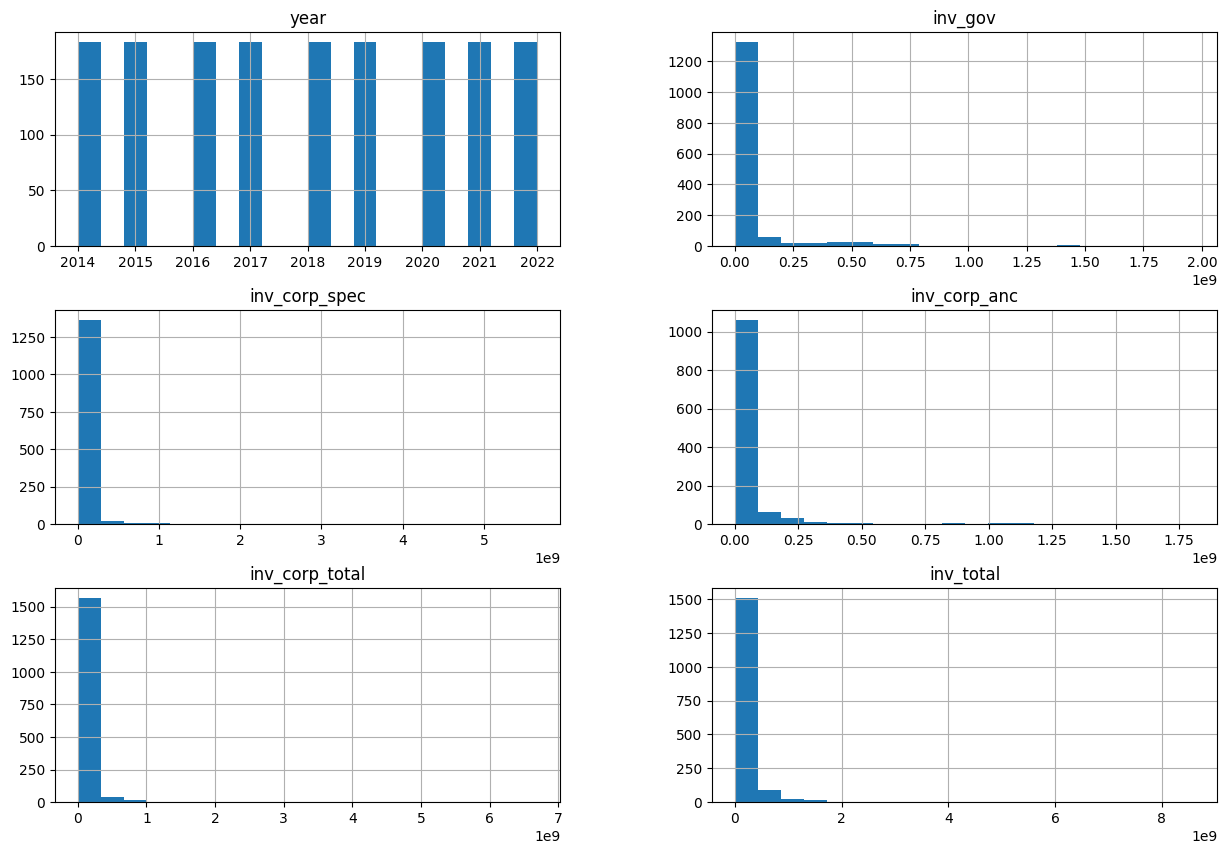


=== 3. Correlation of numeric columns ===


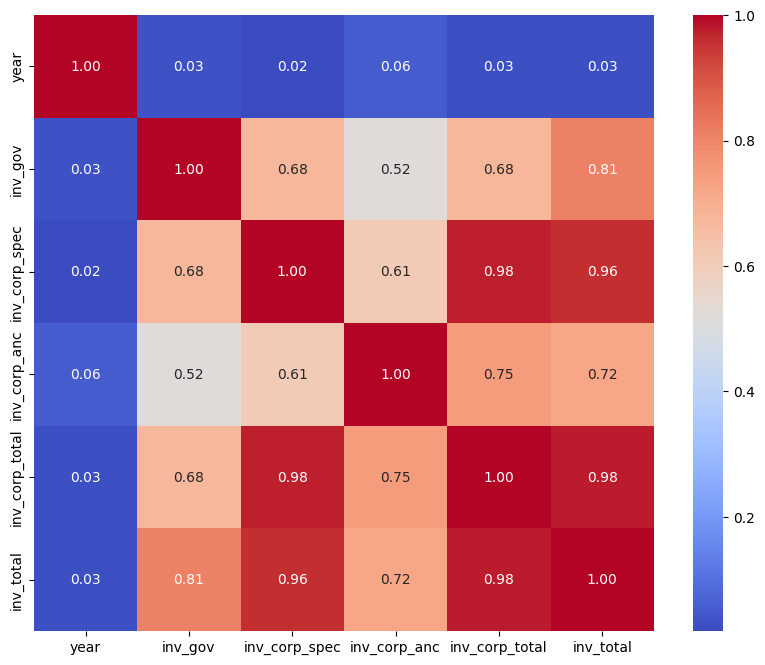

In [42]:
print("=== 1. General information ===")
print("Shape:", df_cepa_breakdown.shape)
print("\nDatatypes:")
print(df_cepa_breakdown.dtypes)
display(df_cepa_breakdown.describe())

print("\n=== 2. Distribution ===")
num_cols = df_cepa_breakdown.select_dtypes(include='number').columns.tolist()
if num_cols:
    # Show histograms
    df_cepa_breakdown[num_cols].hist(bins=20, figsize=(15,10))
    plt.show()

print("\n=== 3. Correlation of numeric columns ===")
if len(num_cols) > 1:
    corr = df_cepa_breakdown[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
    plt.show()

View B: Investment Totals

=== 1. General information ===
Shape: (162, 13)

Datatypes:
year                int64
geo                object
country_name       object
ceparema           object
activity           object
inv_gov             Int64
inv_corp_spec       Int64
inv_corp_anc        Int64
inv_corp_total      Int64
inv_total           Int64
population        float64
inv_per_capita    float64
gdp_per_capita    float64
dtype: object


,year,inv_gov,inv_corp_spec,inv_corp_anc,inv_corp_total,inv_total,population,inv_per_capita,gdp_per_capita
count,162.000000,162.0,154.0,131.0,162.0,162.0,1.620000e+02,162.000000,162.000000
mean,2018.000000,573590740.740741,667979870.12987,471726717.557252,1016451234.567901,1590041975.308642,1.296331e+07,114.736794,33033.765432
std,2.589995,780757055.588755,1604733741.495893,738829723.57271,2226574854.125347,2929072666.719415,1.883161e+07,71.664502,21230.306417
min,2014.000000,8700000.0,1400000.0,1100000.0,0.0,13800000.0,4.281560e+05,9.649779,7770.000000
25%,2016.000000,78250000.0,42725000.0,56750000.0,113100000.0,287625000.0,4.030448e+06,57.097559,15372.500000
50%,2018.000000,302100000.0,134250000.0,196600000.0,258350000.0,635450000.0,7.628542e+06,96.566462,24350.000000
75%,2020.000000,844950000.0,457700000.0,540750000.0,985700000.0,1602050000.0,1.065931e+07,161.041798,44252.500000
max,2022.000000,3692000000.0,8209500000.0,3822200000.0,12031700000.0,15059200000.0,8.323712e+07,290.017235,91760.000000



=== 2. Distribution ===


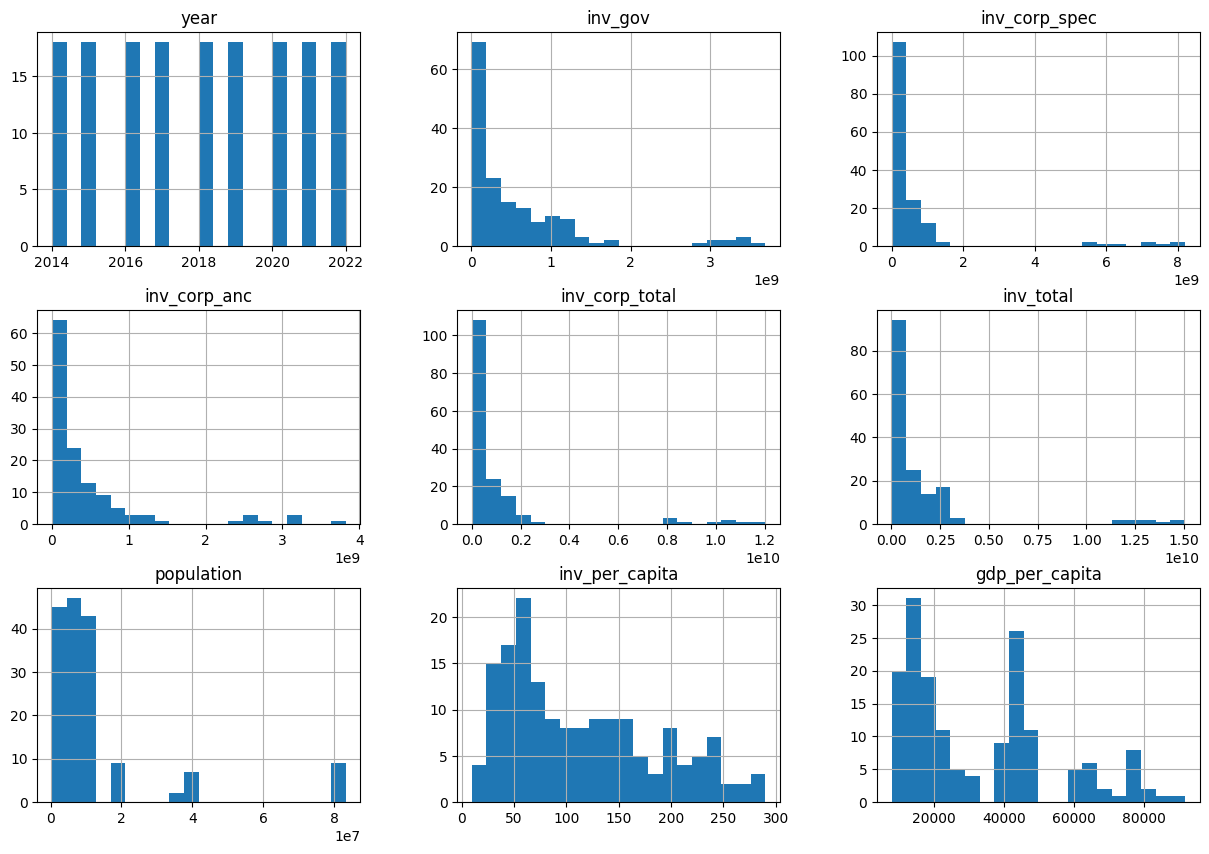


=== 3. Correlation of numeric columns===


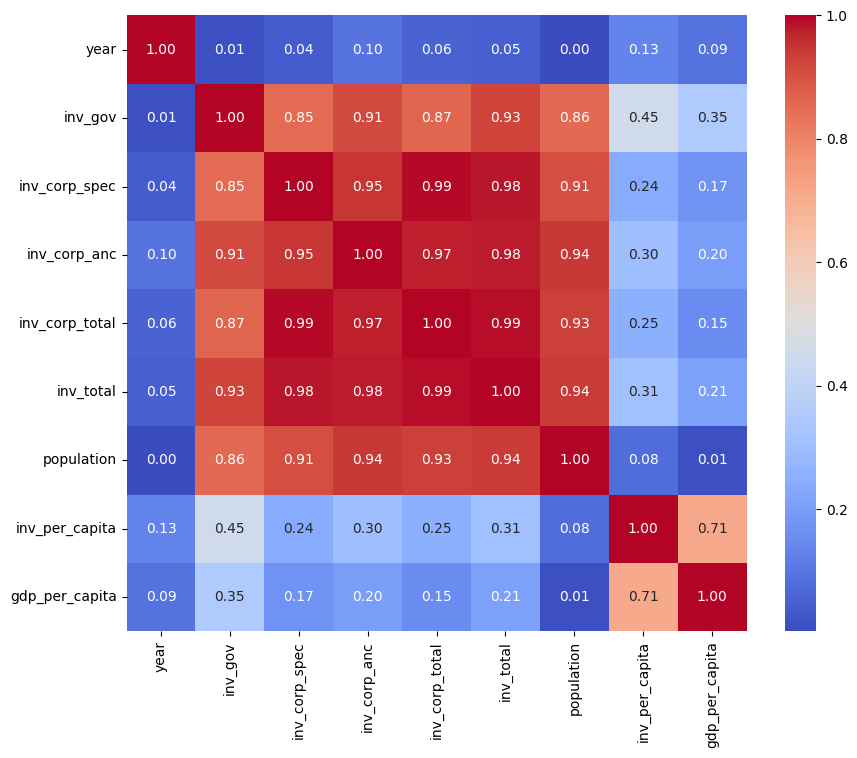

In [43]:
print("=== 1. General information ===")
print("Shape:", df_cepa_totals.shape)
print("\nDatatypes:")
print(df_cepa_totals.dtypes)
display(df_cepa_totals.describe())

print("\n=== 2. Distribution ===")
num_cols = df_cepa_totals.select_dtypes(include='number').columns.tolist()
if num_cols:
    # Show histograms
    df_cepa_totals[num_cols].hist(bins=20, figsize=(15,10))
    plt.show()

print("\n=== 3. Correlation of numeric columns===")
if len(num_cols) > 1:
    corr = df_cepa_totals[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
    plt.show()

## Data Exploration

### Trend Analysis (Investments by Protection Activity & Country)

Successfully saved plot to: ../figures/20260503_env_investment_trends_by_country.png


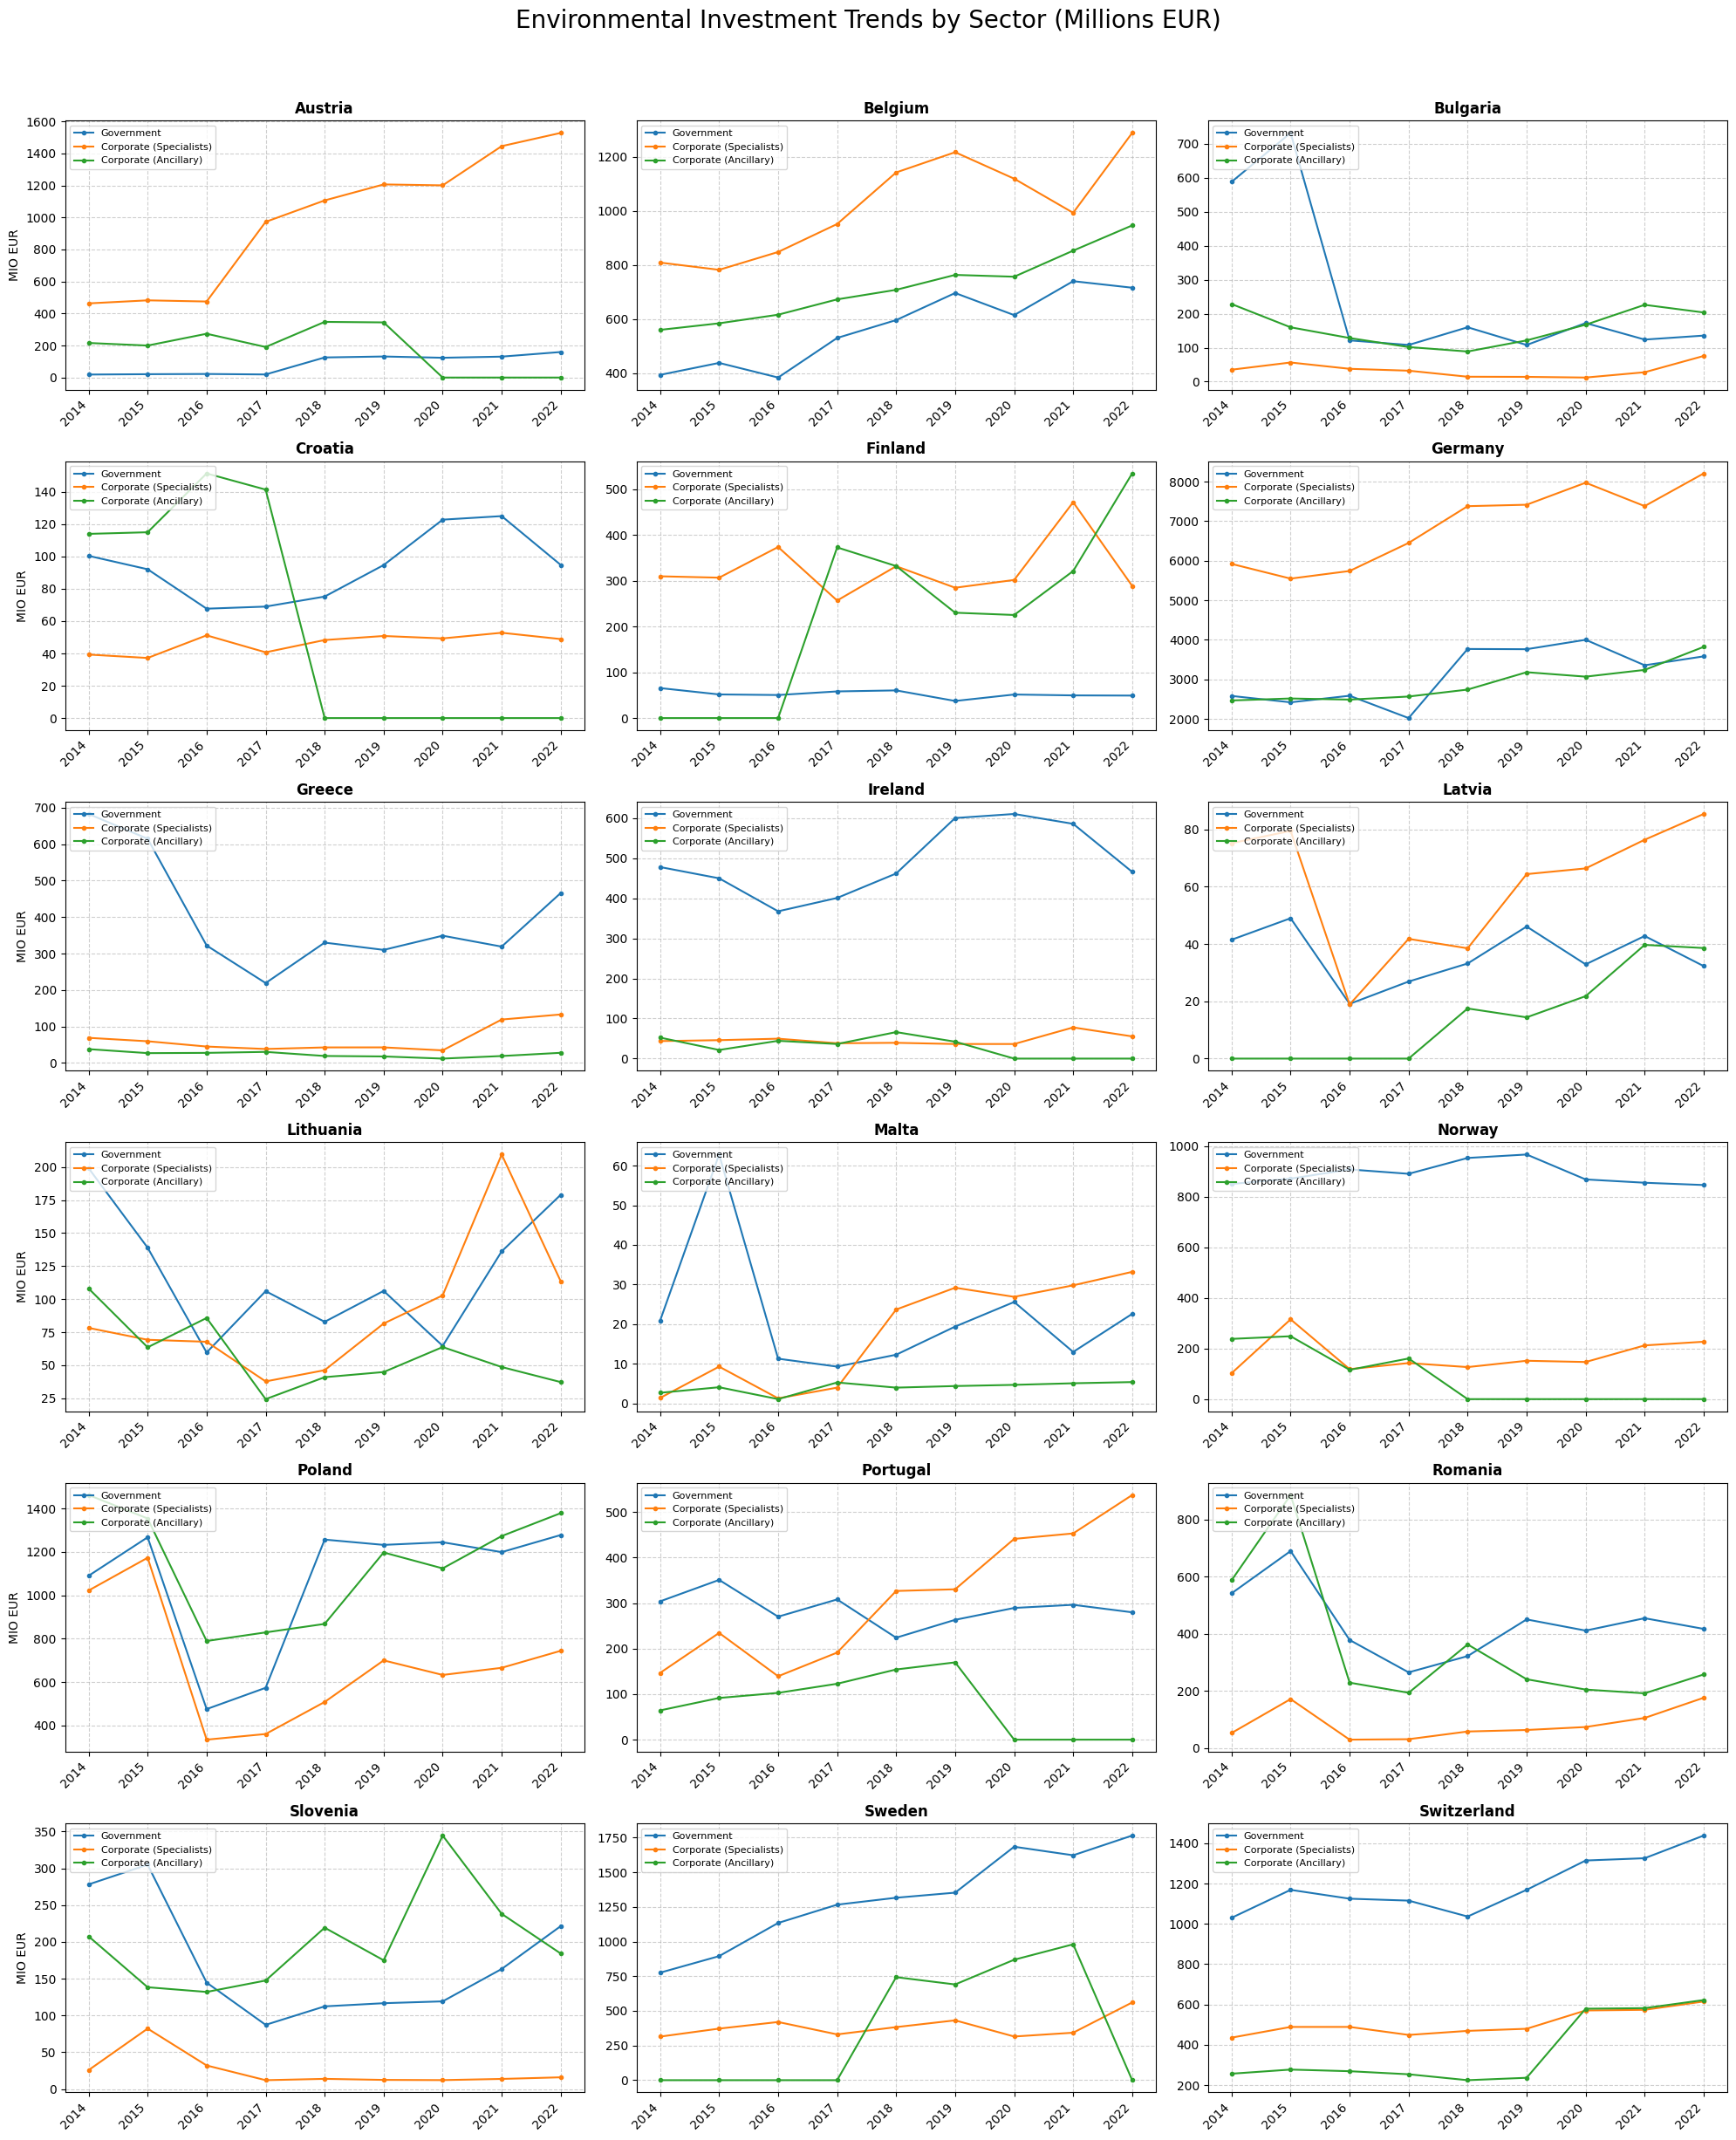

In [ ]:
# Get sorted list of unique countries
countries = sorted(df_cepa_breakdown['country_name'].dropna().unique())
n_countries = len(countries)

# Calculate Layout
cols = 3
rows = (n_countries // cols) + (1 if n_countries % cols > 0 else 0)

# Create the figure
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

# Define labels and colors
# Using a clear color scheme: Blue for Government, Orange for Corporate (Specialists), Green for Corporate (Ancillary)
for i, country in enumerate(countries):
    ax = axes[i]
    
    # Filter data for the specific country
    c_data = df_cepa_breakdown[df_cepa_breakdown['country_name'] == country]
    
    # Group by year and sum values, converting to Millions for readability (MIO EUR)
    gov_trend = c_data.groupby('year')['inv_gov'].sum() / 1_000_000
    spec_trend = c_data.groupby('year')['inv_corp_spec'].sum() / 1_000_000
    anc_trend = c_data.groupby('year')['inv_corp_anc'].sum() / 1_000_000
    
    # Plotting each investment stream separately
    ax.plot(gov_trend.index, gov_trend.values, 
            label='Government', color='#1f77b4', marker='.', linewidth=1.5)
    
    ax.plot(spec_trend.index, spec_trend.values, 
            label='Corporate (Specialists)', color='#ff7f0e', marker='.', linewidth=1.5)
    
    ax.plot(anc_trend.index, anc_trend.values, 
            label='Corporate (Ancillary)', color='#2ca02c', marker='.', linewidth=1.5)
    
    # Formatting the subplot
    ax.set_title(country, fontsize=12, fontweight='bold')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(True, linestyle='--', alpha=0.6)

    # Rotate the ticks for the year axis to avoid overlapping
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Add legend to the subplot
    ax.legend(fontsize=8, loc='upper left')
    
    # Add Y-label to the first column only to save space and reduce clutter
    if i % cols == 0:
        ax.set_ylabel('MIO EUR')

# Delete empty subplots at the end of the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Main title for the entire figure
plt.suptitle('Environmental Investment Trends by Sector (Millions EUR)', fontsize=20, y=1.02)
plt.tight_layout()

# Save the figure
plot_filename = f"{current_date}_investment_trends_by_country.png"
try:
    export_path = os.path.join(FIGURES_PATH, plot_filename)
except NameError:
    export_path = plot_filename

plt.savefig(export_path, bbox_inches='tight', dpi=300)
print(f"Successfully saved plot to: {export_path}")

Be careful: The y-axis has a different range for each country. Each country must be considered separately. 

### Category Analysis (Investments by Protection Activity & Sector)

Category plot saved successfully to: ../figures/20260503_env_investment_by_protection_activity.png


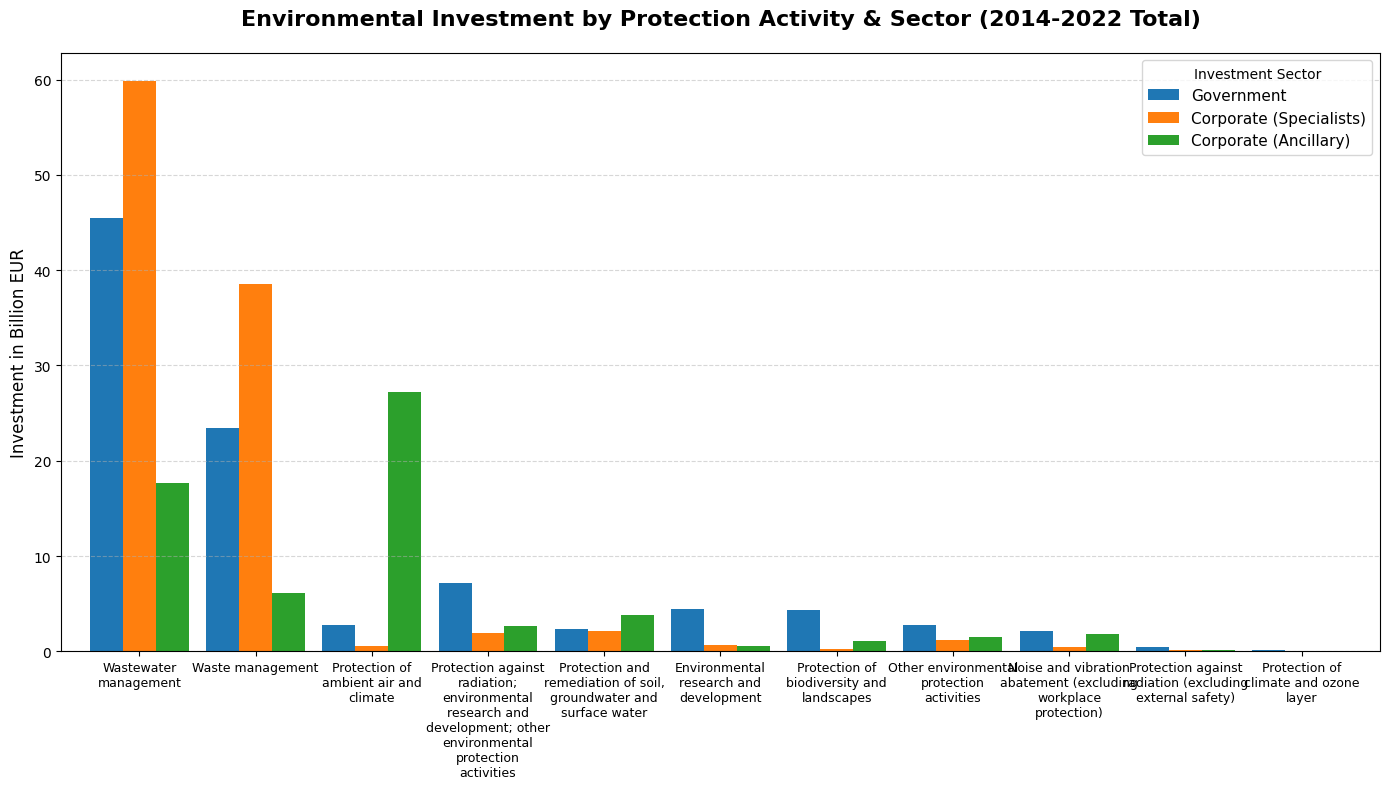

In [ ]:
# Group by activity and sum all three investment streams
category_summary = df_cepa_breakdown.groupby('activity')[['inv_gov', 'inv_corp_spec', 'inv_corp_anc']].sum()

# Convert values to Billion EUR (Divide by 10^9)
category_summary = category_summary / 1_000_000_000

# Sort the categories based on the combined total effort (Gov + Spec + Anc)
category_summary['total_sum'] = category_summary.sum(axis=1)
category_summary = category_summary.sort_values(by='total_sum', ascending=False).drop(columns='total_sum')

# Wrap long category names into multiple lines for better readability
wrapped_labels = [textwrap.fill(label, width=20) for label in category_summary.index]
category_summary.index = wrapped_labels

# Create the vertical bar chart
# Using a grouped bar chart to compare the three sectors side-by-side
ax = category_summary.plot(
    kind='bar', 
    figsize=(14, 8), 
    color=['#1f77b4', '#ff7f0e', '#2ca02c'], # Blue, Orange, Green
    width=0.85
)

# Add styling and labels
plt.title('Environmental Investment by Protection Activity & Sector (2014-2022 Total)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Investment in Billion EUR', fontsize=12)
plt.xlabel('', fontsize=12)
plt.xticks(rotation=0, fontsize=9) # Keeps wrapped labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Clear legend with specific descriptions
plt.legend(
    ['Government', 'Corporate (Specialists)', 'Corporate (Ancillary)'], 
    title='Investment Sector', 
    fontsize=11
)

# Optimize layout to prevent text clipping
plt.tight_layout()

# --- Save Figure ---
cat_plot_filename = f"{current_date}_investment_by_protection_activity.png"
try:
    cat_save_path = os.path.join(FIGURES_PATH, cat_plot_filename)
except NameError:
    cat_save_path = cat_plot_filename

plt.savefig(cat_save_path, bbox_inches='tight', dpi=300)
print(f"Category plot saved successfully to: {cat_save_path}")

### Correlation Analysis (Investments Total)

Scatter plot saved successfully to: ../figures/20260503_gdp_investment_correlation.png
The Pearson correlation coefficient is: 0.71


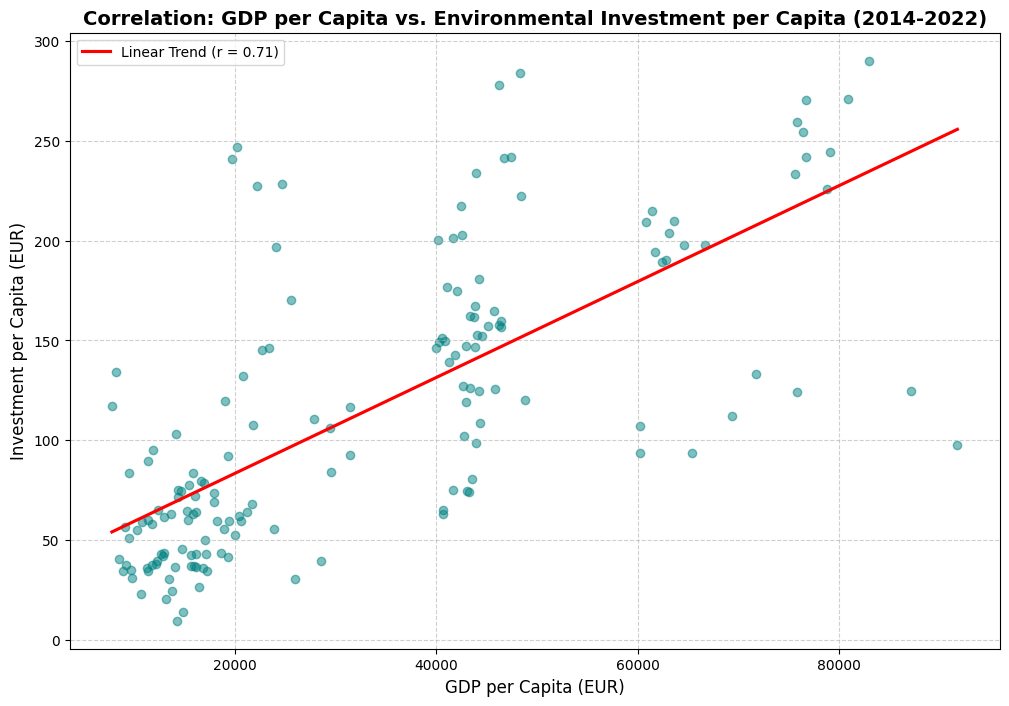

In [46]:
# Use the df_cepa_totals to avoid double counting
df_scatterplot = df_cepa_totals.dropna(subset=['gdp_per_capita', 'inv_per_capita']).copy()

# Create the Scatterplot with a regression line
plt.figure(figsize=(12, 8))

# Using regplot to show the linear relationship between wealth and effort
sns.regplot(
    data=df_scatterplot, 
    x='gdp_per_capita', 
    y='inv_per_capita',
    ci=None,
    scatter_kws={'alpha': 0.5, 'color': 'teal'},
    line_kws={'color': 'red', 'label': f'Linear Trend (r = {df_scatterplot["gdp_per_capita"].corr(df_scatterplot["inv_per_capita"]):.2f})'}
)

# Styling and Labels
plt.title('Correlation: GDP per Capita vs. Environmental Investment per Capita (2014-2022)', fontsize=14, fontweight='bold')
plt.xlabel('GDP per Capita (EUR)', fontsize=12)
plt.ylabel('Investment per Capita (EUR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save Figure
scatter_plot_filename = f"{current_date}_gdp_investment_correlation.png"
try:
    scatter_save_path = os.path.join(FIGURES_PATH, scatter_plot_filename)
except NameError:
    scatter_save_path = scatter_plot_filename

plt.savefig(scatter_save_path, bbox_inches='tight', dpi=300)
print(f"Scatter plot saved successfully to: {scatter_save_path}")

# Statistical Output
correlation = df_scatterplot['gdp_per_capita'].corr(df_scatterplot['inv_per_capita'])
print(f"The Pearson correlation coefficient is: {correlation:.2f}")

## Modeling

### Unsupervised Learning: Clustering (Investments Total)

To understand how different European nations prioritize their environmental protection efforts, we perform a K-Means Clustering analysis. This method groups countries based on their "investment profile" rather than their absolute spending.

Environmental investment data reported to Eurostat can be fragmented. 

First, a small analysis is done to identify the year with the fewest missing values across all core investment pillars (inv_gov, inv_corp_spec, inv_corp_anc). Based on the results, 2019 was chosen as it is the most current dataset with the highest number of available countries. 

Machine Learning algorithms like K-Means and the StandardScaler cannot process missing values (NaN).

Constraint: We applied Listwise Deletion, meaning only countries with a complete data record for all selected variables were included in the clustering.

Relative Structural Shares rather than comparing absolute Euro amounts are used for the clustering. Otherwise it would naturally favor larger economies like Germany or France

The resulting clusters are visualized in a multi-dimensional scatterplot:
- X-Axis: The state's involvement (Government Share).
- Y-Axis: Specialist Corporation Share.
- Bubble Size: Ancillary Corporation Share.

This visualization identifies distinct "profiles" of environmental protection strategies across the European landscape.

In [48]:
# List of columns that must not be NaN for the clustering to work
cluster_cols = ['inv_gov', 'inv_corp_spec', 'inv_corp_anc', 'geo']

# Count non-NaN rows per year for these specific columns
# We use .dropna() on the subset and then count the remaining rows per year
availability_per_year = (
    df_cepa_totals.dropna(subset=cluster_cols)
    .groupby('year')
    .size()
    .sort_values(ascending=False)
)

print("=== Data Availability per Year (Clean Rows) ===")
print(availability_per_year)

# Identify the best year automatically
best_year = availability_per_year.idxmax()
max_countries = availability_per_year.max()

=== Data Availability per Year (Clean Rows) ===
year
2018    16
2019    16
2017    15
2014    14
2015    14
2016    14
2020    13
2021    13
2022    12
dtype: int64


Cluster plot saved successfully to: ../figures/20260503_investment_structure_clusters_2019.png


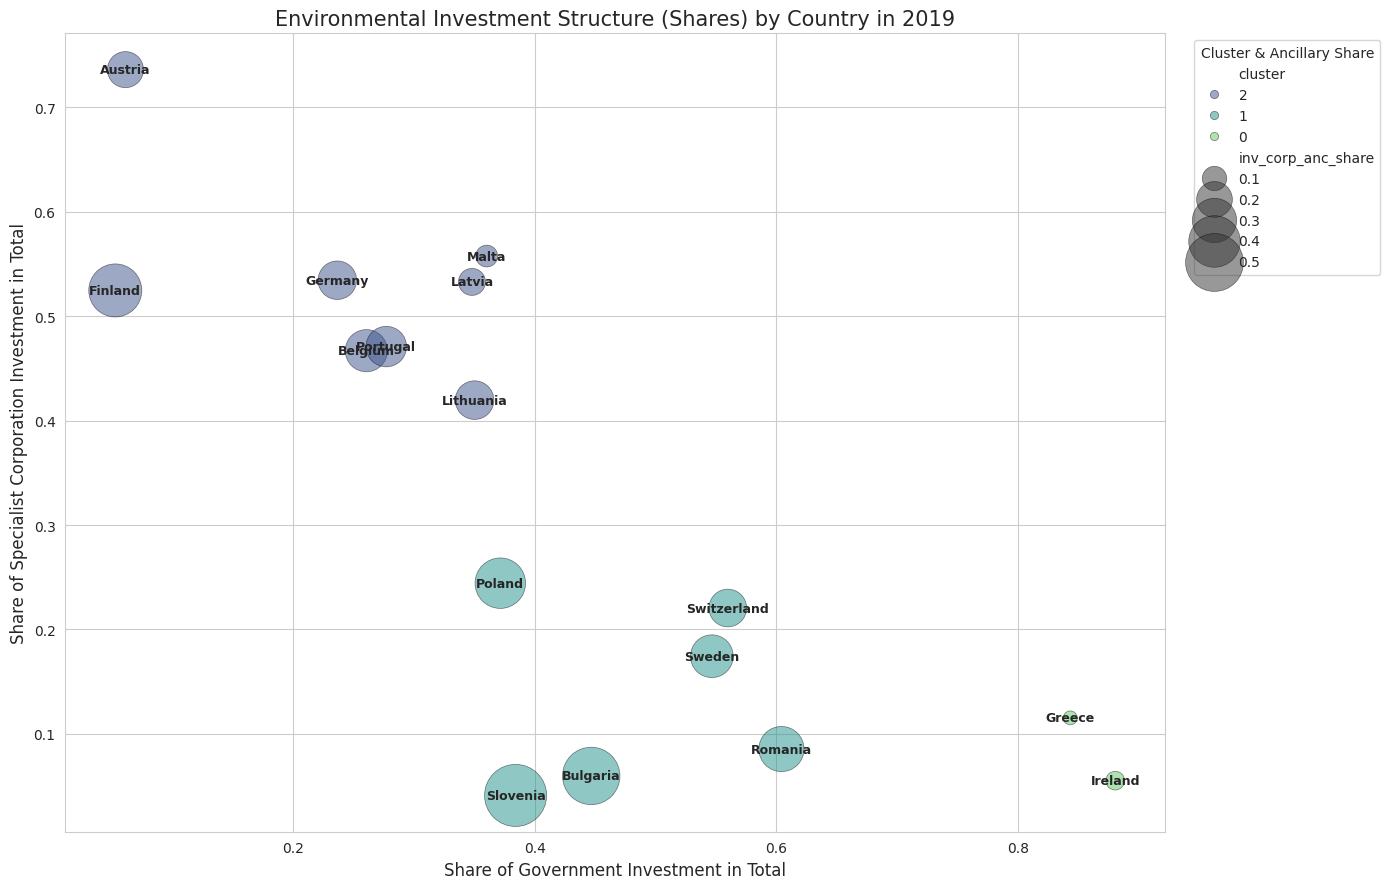

In [ ]:
# Preparation 
year_to_analyze = 2019
df_cluster = df_cepa_totals[df_cepa_totals['year'] == year_to_analyze].copy()

# Specify core investment columns and the total base for share calculation
cluster_cols = ['inv_gov', 'inv_corp_spec', 'inv_corp_anc']
base_col = 'inv_total'

# Data Cleaning: Remove rows with NaNs in critical columns and ensure total investment > 0
# We also include 'country_name' in the subset to ensure every point can be labeled
df_cluster = df_cluster.dropna(subset=cluster_cols + [base_col, 'country_name'])
df_cluster = df_cluster[df_cluster[base_col] > 0]

# Type Conversion: Convert to standard float to prevent TypeErrors in visualization libraries
for col in cluster_cols + [base_col]:
    df_cluster[col] = df_cluster[col].astype(float)

# Feature Engineering: Calculate shares (Investment Type / Total Investment)
# Result: Values between 0 and 1 (e.g., 0.35 represents a 35% share)
for col in cluster_cols:
    df_cluster[f'{col}_share'] = df_cluster[col] / df_cluster[base_col]

share_cols = [f'{col}_share' for col in cluster_cols]

# Clustering
# Standardize features to have a mean of 0 and variance of 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[share_cols])

# Apply K-Means clustering based on investment structure (shares)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled).astype(str)

# --- 3. Visualization ---
plt.figure(figsize=(14, 9))
sns.set_style("whitegrid")

# Create Scatterplot
# X-axis: Government share, Y-axis: Specialist corp share, Size: Ancillary corp share
scatter = sns.scatterplot(
    data=df_cluster,
    x='inv_gov_share',
    y='inv_corp_spec_share',
    size='inv_corp_anc_share',
    hue='cluster',
    palette='viridis',
    sizes=(100, 2000), 
    alpha=0.5,
    edgecolor='black',
    linewidth=0.5
)

# Country Annotation
# Label each point with the full country name
for i in range(len(df_cluster)):
    plt.text(
        x=df_cluster['inv_gov_share'].iloc[i], 
        y=df_cluster['inv_corp_spec_share'].iloc[i], 
        s=df_cluster['country_name'].iloc[i],
        fontsize=9,
        fontweight='bold',
        ha='center',
        va='center'
    )

# Final Plot Adjustments
plt.title(f'Environmental Investment Structure (Shares) by Country in {year_to_analyze}', fontsize=15)
plt.xlabel('Share of Government Investment in Total', fontsize=12)
plt.ylabel('Share of Specialist Corporation Investment in Total', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Cluster & Ancillary Share')
plt.tight_layout()

# Save Figure
# Professional filename including the analysis year for better tracking
cluster_plot_filename = f"{current_date}_investment_clusters_{year_to_analyze}.png"

try:
    cluster_save_path = os.path.join(FIGURES_PATH, cluster_plot_filename)
except NameError:
    cluster_save_path = cluster_plot_filename

# Save with high resolution and tight bounding box
plt.savefig(cluster_save_path, bbox_inches='tight', dpi=300)
print(f"Cluster plot saved successfully to: {cluster_save_path}")

plt.show()

### Supervised Learning: Time Series Panel Regression (Investments Total)

1. Input Features (Independent Variables $X$)
To simulate causality and account for country-specific characteristics, the model utilizes both **lagged features** and **Entity Fixed Effects**. Economic indicators are log-transformed to normalize right-skewed distributions and improve model stability.

| Feature | Description | Transformation |
| :--- | :--- | :--- |
| **log_gdp_lag1** | Economic power (GDP per capita) from the previous year. | `log1p` + `shift(1)` |
| **log_pop_lag1** | Demographic size (population) from the previous year. | `log1p` + `shift(1)` |
| **inv_lag1** | Environmental protection investments per capita from the previous year. | `shift(1)` |
| **country_name_*** | Binary indicators (Dummies) for each country. | `pd.get_dummies` |

**Methodological Note:** By using **Fixed Effects** (Country Dummies), the model learns a baseline investment level for each specific country. This accounts for unobserved factors—such as national policy or institutional frameworks—that remain stable over time.

2. Target Variable (Dependent Variable $y$)
The model predicts the investment level for the current year based on the previous year's performance and structural data.

| Variable | Description | Unit |
| :--- | :--- | :--- |
| **inv_per_capita** | Total environmental protection investments divided by population. | Euro (€) per capita |

---

3. Experiment Setup

Methodology & Validation
* **Time-Based Split:** A chronological split is used to evaluate the model's forecasting performance on future data:
    * **Training Set:** Data from 2015 to 2020.
    * **Test Set:** Data from 2021 and 2022.
* **Algorithms:**
    * **Random Forest Regressor (Fixed Effects):** An ensemble model using **200 trees** and a `max_depth` of **10** to capture non-linear patterns and country-specific interactions.
    * **Linear Regression (Fixed Effects):** A standard OLS (Ordinary Least Squares) approach that estimates linear relationships while controlling for länderspezifische intercepts.

Evaluation Metrics
The models are evaluated on the unseen test data (2021–2022) using:
* **$R^2$ (Coefficient of Determination):** Measures the proportion of variance in investments explained by the model.
* **MAE (Mean Absolute Error):** The average absolute error in Euro per capita.
* **RMSE (Root Mean Squared Error):** Measures the average error magnitude, giving higher weight to large outliers.

In [50]:
# --- Preparation ---
# Sort by country and year to ensure lags are calculated correctly chronologically
df_ml = df_cepa_totals.copy().sort_values(['country_name', 'year'])

# Apply Log-Transformations to handle skewed distributions and non-linear relationships
df_ml['log_gdp'] = np.log1p(df_ml['gdp_per_capita'])
df_ml['log_pop'] = np.log1p(df_ml['population'])

# Create Lagged Features (t-1) to model temporal dependencies
# Shifting by 1 year within each country group
df_ml['log_gdp_lag1'] = df_ml.groupby('country_name')['log_gdp'].shift(1)
df_ml['log_pop_lag1'] = df_ml.groupby('country_name')['log_pop'].shift(1)
df_ml['inv_lag1'] = df_ml.groupby('country_name')['inv_per_capita'].shift(1)

# Add Country Dummies (Fixed Effects) to account for country-specific intercepts
df_ml = pd.get_dummies(df_ml, columns=['country_name'], drop_first=True)

# Remove NaN values generated by lagging and existing gaps
df_ml = df_ml.dropna()

# --- Time-Based Split ---
# Splitting data by time to evaluate predictive performance on "future" years (2021 onwards)
train_df = df_ml[df_ml['year'] < 2021]
test_df = df_ml[df_ml['year'] >= 2021]

# Define feature list (Lags + Fixed Effect Dummies) and target variable
features = ['log_gdp_lag1', 'log_pop_lag1', 'inv_lag1'] + [col for col in df_ml.columns if 'country_name_' in col]
target = 'inv_per_capita'

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# --- Model Training ---
# Random Forest handles different scales naturally; Linear Regression with dummies is also stable
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
lr_model = LinearRegression()

rf_model.fit(X_train, y_train) 
lr_model.fit(X_train, y_train) 

# --- Prediction & Metrics Evaluation ---
results = []

# Random Forest Evaluation
rf_preds = rf_model.predict(X_test)
results.append({
    "Model": "Random Forest",
    "MAE": mean_absolute_error(y_test, rf_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, rf_preds)),
    "R2": r2_score(y_test, rf_preds)
})

# Linear Regression Evaluation
lr_preds = lr_model.predict(X_test)
results.append({
    "Model": "Linear Regression",
    "MAE": mean_absolute_error(y_test, lr_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, lr_preds)),
    "R2": r2_score(y_test, lr_preds)
})

# Display Performance Comparison Table
perf_df = pd.DataFrame(results)
print("\n" + "="*40)
print("PERFORMANCE COMPARISON")
print("="*40)
print(perf_df.to_string(index=False))

# --- Exporting Results Table as CSV ---
results_filename = os.path.join(RESULTS_PATH, f"{current_date}_reg_model_performance_comparison.csv")
perf_df.to_csv(results_filename, index=False)
print(f"Results table saved to: {os.path.basename(results_filename)}")


PERFORMANCE COMPARISON
            Model       MAE      RMSE       R2
    Random Forest 16.196572 20.164169 0.934635
Linear Regression 19.412825 23.782052 0.909075
Results table saved to: 20260503_reg_model_performance_comparison.csv


Regression comparison plot saved successfully to: ../figures/20260503_regression_performance_comparison.png


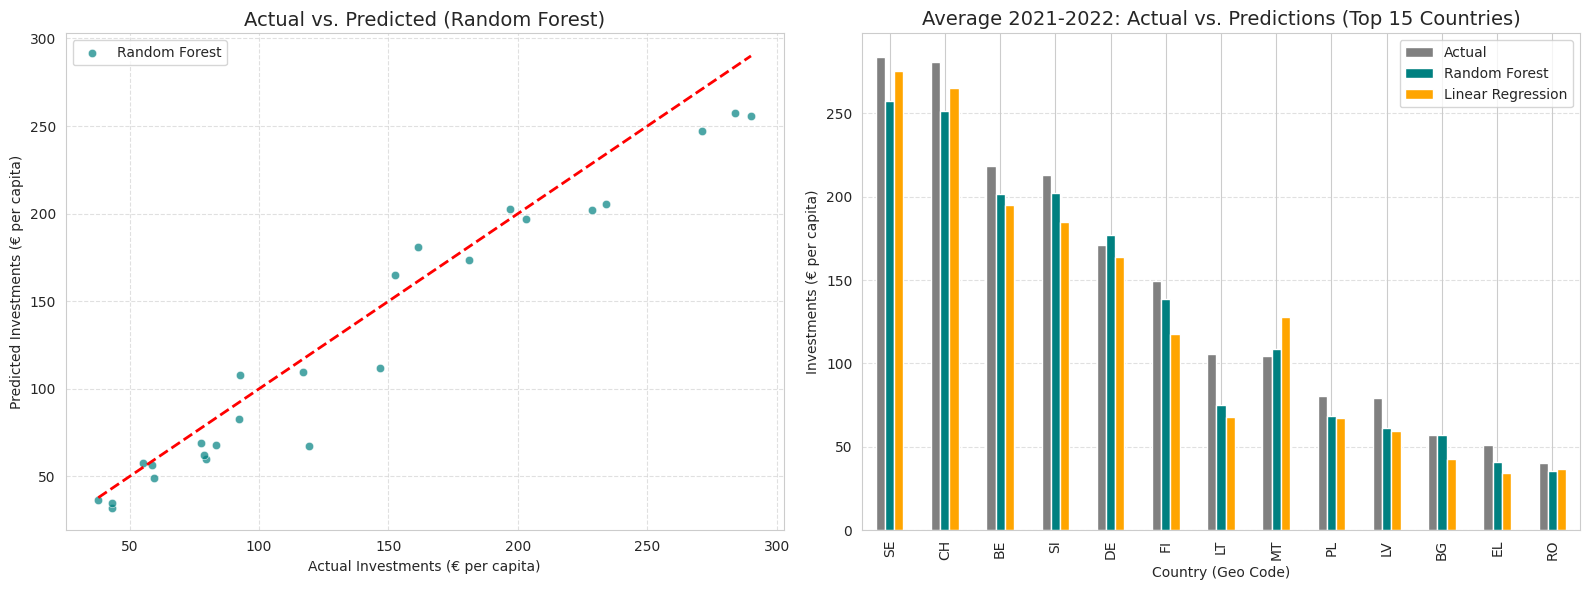

In [51]:
# --- Data Preparation for Visualization ---
# Creating a dedicated DataFrame for comparison of actual values and predictions
df_plot = pd.DataFrame({
    'Actual': y_test,
    'RF_Pred': rf_preds,
    'LR_Pred': lr_preds
}).reset_index()

# Retrieve geographical codes (geo) using the original index from the test set
# This ensures that each prediction is correctly mapped back to its country
df_plot['geo'] = df_cepa_totals.loc[y_test.index, 'geo'].values

plt.figure(figsize=(16, 6))

# --- Plot 1: Actual vs. Predicted (Random Forest) ---
# This scatter plot visualizes model accuracy: points closer to the red dashed line (identity line) 
# represent more accurate predictions.
plt.subplot(1, 2, 1)
sns.scatterplot(x='Actual', y='RF_Pred', data=df_plot, color='teal', alpha=0.7, label='Random Forest')
# Drawing the 45-degree identity line (perfect prediction reference)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) 
plt.title('Actual vs. Predicted (Random Forest)', fontsize=14)
plt.xlabel('Actual Investments (€ per capita)')
plt.ylabel('Predicted Investments (€ per capita)')
plt.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Direct Comparison of Top 15 Countries ---
# Analyzing the mean performance over the test period (2021-2022) per country
plt.subplot(1, 2, 2)
# Grouping by 'geo' and calculating the average to simplify the comparison
compare_countries = df_plot.groupby('geo').mean(numeric_only=True).sort_values('Actual', ascending=False).head(15)
compare_countries[['Actual', 'RF_Pred', 'LR_Pred']].plot(
    kind='bar', 
    ax=plt.gca(), 
    color=['gray', 'teal', 'orange']
)

plt.title('Average 2021-2022: Actual vs. Predictions (Top 15 Countries)', fontsize=14)
plt.ylabel('Investments (€ per capita)')
plt.xlabel('Country (Geo Code)')
plt.legend(["Actual", "Random Forest", "Linear Regression"])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# --- Save Regression Comparison Figure ---
# Saving both subplots as one combined image for the report
regression_plot_filename = f"{current_date}_regression_performance_comparison.png"

try:
    # Use the pre-defined FIGURES_PATH
    regression_save_path = os.path.join(FIGURES_PATH, regression_plot_filename)
except NameError:
    # Fallback to local directory if FIGURES_PATH is not accessible
    regression_save_path = regression_plot_filename

plt.savefig(regression_save_path, bbox_inches='tight', dpi=300)
print(f"Regression comparison plot saved successfully to: {regression_save_path}")

plt.show()

In [52]:
# --- Exporting Models for Reproducibility ---

# Define filenames for the models
rf_filename = os.path.join(MODELS_PATH, f"{current_date}_random_forest_regression.joblib")
lr_filename = os.path.join(MODELS_PATH, f"{current_date}_linear_regression.joblib")

# --- Exporting Models for Reproducibility ---
try:
    # Ensure the models directory exists
    os.makedirs(MODELS_PATH, exist_ok=True)
    
    # Save Random Forest Regressor
    joblib.dump(rf_model, rf_filename)
    # Save Linear Regression Model
    joblib.dump(lr_model, lr_filename)
    
    print("="*40)
    print("MODEL EXPORT SUCCESSFUL")
    print("="*40)
    print(f"Saved: {os.path.basename(rf_filename)}")
    print(f"Saved: {os.path.basename(lr_filename)}")
    print(f"Path:  {os.path.abspath(MODELS_PATH)}")

except Exception as e:
    print(f"An error occurred while saving the models: {e}")

MODEL EXPORT SUCCESSFUL
Saved: 20260503_random_forest_regression.joblib
Saved: 20260503_linear_regression.joblib
Path:  /home/daniel/projects/SS2026_TU_Wien/Data_Stewardship/Environmental_Protection_Investment_Analysis/models
